In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


Matplotlib is building the font cache; this may take a moment.


**LOAD THE DATA**

In [13]:
df_us= pd.read_csv('../../data/processed/us_df.csv', index_col=0)
df_us.head()

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Cotton Supply and Use,Avg. farm price,NaN,Cotton,United States,2007/08,NaN,Annual,59.30,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Beginning stocks,NaN,Cotton,United States,2007/08,NaN,Annual,9.48,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Domestic use,NaN,Cotton,United States,2007/08,NaN,Annual,4.59,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Ending stocks,NaN,Cotton,United States,2007/08,NaN,Annual,10.04,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,"Exports, total",NaN,Cotton,United States,2007/08,NaN,Annual,13.65,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4


# **INITIAL CLEANING**

In [12]:
# Investigate reliability projection
df_us["ReliabilityProjection"].value_counts(dropna=False)

,count
ReliabilityProjection,
NaN,273893
above_final,9400
below_final,9400
average,8750
root_mean_square_error,8750
smallest,8750
largest,8750
confidence_interval,8750
average_percent,650


In [13]:
df_us.groupby("ReliabilityProjection")["ReportTitle"].value_counts()

ReliabilityProjection  ReportTitle                                      
above_final            Reliability of United States April Projections       510
                       Reliability of United States December Projections    480
                       Reliability of United States February Projections    480
                       Reliability of United States July Projections        480
                       Reliability of United States June Projections        480
                                                                           ... 
smallest               Reliability of November Projections                  300
                       Reliability of September Projections                 300
                       Reliability of August Projections                    280
                       Reliability of January Projections                   280
                       Reliability of October Projections                   240
Name: count, Length: 264, dtype: int64

In [14]:
df_us["ReportTitle"].value_counts()

,count
ReportTitle,
U.S. Meats Supply and Use,31752
"U.S. Sorghum, Barley, and Oats Supply and Use",24171
U.S. Rice Supply and Use,21476
U.S. Soybeans and Products Supply and Use (Domestic Measure),19524
U.S. Quarterly Animal Product Production,18711
U.S. Feed Grain and Corn Supply and Use,17099
U.S. Wheat by Class: Supply and Use,16068
U.S. Quarterly Prices for Animal Products,15937
U.S. Milk Supply and Use,14008


In [15]:
df_us["ReportTitle"].nunique()

50

In [16]:
sorted(df_us["ReportTitle"].unique())

['Reliability of April Projections',
 'Reliability of August Projections',
 'Reliability of December Projections',
 'Reliability of February Projections',
 'Reliability of January Projections',
 'Reliability of July Projections',
 'Reliability of June Projections',
 'Reliability of March Projections',
 'Reliability of May Projections',
 'Reliability of November Projections',
 'Reliability of October Projections',
 'Reliability of September Projections',
 'Reliability of United States April Projections',
 'Reliability of United States August Projections',
 'Reliability of United States December Projections',
 'Reliability of United States February Projections',
 'Reliability of United States January Projections',
 'Reliability of United States July Projections',
 'Reliability of United States June Projections',
 'Reliability of United States March Projections',
 'Reliability of United States May Projections',
 'Reliability of United States November Projections',
 'Reliability of United 

In [17]:
# Filtering out reliability projection
df_us = df_us[
    ~df_us["ReportTitle"].str.contains("Reliability", na=False)
]

In [18]:
us_reports = df_us["ReportTitle"].value_counts()
us_reports

,count
ReportTitle,
U.S. Meats Supply and Use,31752
"U.S. Sorghum, Barley, and Oats Supply and Use",24171
U.S. Rice Supply and Use,21476
U.S. Soybeans and Products Supply and Use (Domestic Measure),19524
U.S. Quarterly Animal Product Production,18711
U.S. Feed Grain and Corn Supply and Use,17099
U.S. Wheat by Class: Supply and Use,16068
U.S. Quarterly Prices for Animal Products,15937
U.S. Milk Supply and Use,14008


In [19]:
us_reports[us_reports.index.str.startswith("U.S.")]

,count
ReportTitle,
U.S. Meats Supply and Use,31752
"U.S. Sorghum, Barley, and Oats Supply and Use",24171
U.S. Rice Supply and Use,21476
U.S. Soybeans and Products Supply and Use (Domestic Measure),19524
U.S. Quarterly Animal Product Production,18711
U.S. Feed Grain and Corn Supply and Use,17099
U.S. Wheat by Class: Supply and Use,16068
U.S. Quarterly Prices for Animal Products,15937
U.S. Milk Supply and Use,14008


In [20]:
df_us["ReportTitle"].str.contains("Reliability", na=False).sum()

np.int64(0)

The original dataset contains both standard WASDE reports and reliability reports. Reliability reports summarize historical forecast accuracy (e.g., RMSE, confidence intervals, forecast bias) rather than commodity supply and demand observations. Since the objective of this project is to analyze and forecast commodity data, these reports were removed from the dataset.

In [21]:
# Check data types
df_us.dtypes

,0
WasdeNumber,int64
ReportDate,object
ReportTitle,object
Attribute,object
ReliabilityProjection,object
Commodity,object
Region,object
MarketYear,object
ProjEstFlag,object
AnnualQuarterFlag,object


In [22]:
# Convert releasedate to datetime
df_us["ReleaseDate"] = pd.to_datetime(
    df_us["ReleaseDate"],
    format="mixed"
)
df_us["ReleaseDate"].dtype

dtype('<M8[ns]')

In [23]:
df_us["Value"] = pd.to_numeric(df_us["Value"], errors="coerce")

In [24]:
df_us.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273893 entries, 552 to 928850
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   WasdeNumber            273893 non-null  int64         
 1   ReportDate             273893 non-null  object        
 2   ReportTitle            273893 non-null  object        
 3   Attribute              273893 non-null  object        
 4   ReliabilityProjection  0 non-null       object        
 5   Commodity              273893 non-null  object        
 6   Region                 273893 non-null  object        
 7   MarketYear             273893 non-null  object        
 8   ProjEstFlag            166871 non-null  object        
 9   AnnualQuarterFlag      273893 non-null  object        
 10  Value                  273183 non-null  float64       
 11  Unit                   273893 non-null  object        
 12  ReleaseDate            273893 non-null  datetim

Investigating the rows

In [25]:
df_us["Commodity"].value_counts()

,count
Commodity,
Wheat,15956
Cotton,14288
Corn,13157
Sugar,12438
"Oilseed, Soybean",12014
...,...
TOTAL POULTRY,24
BEEF,24
BROILER,24


In [26]:
df_us["Attribute"].value_counts()

,count
Attribute,
Production,38742
Ending Stocks,21497
Imports,18309
Exports,17937
Beginning Stocks,15048
...,...
For methyl ester,3
Food seed & industrial,3
Other program,3


In [27]:
df_us["Unit"].value_counts()

,count
Unit,
Million Pounds,52668
Million Bushels,52302
Million Metric Tons,52137
Billion Pounds,15319
Million Hundredweight,14297
"1000 Short Tons, Raw Value",12438
Million Dozen,8127
Dol./cwt,7990
Million Acres,6804


This suggests that each commodity should have its own time series.

In [28]:
df_us["MarketYear"].value_counts().sort_index()

,count
MarketYear,
2007,38
2007/08,290
2008,565
2008/09,3812
2009,2158
2009/10,7836
2010,4396
2010/011,482
2010/11,11054


# **Understanding the data**

In [29]:
# open market commodities
corn = df_us[
    df_us["ReportTitle"] == "U.S. Feed Grain and Corn Supply and Use"
]
soybeans = df_us[
    df_us["ReportTitle"] == "U.S. Soybeans and Products Supply and Use (Domestic Measure)"
]
cotton = df_us[
    df_us["ReportTitle"] == "U.S. Cotton Supply and Use"
]
wheat = df_us[
    df_us["ReportTitle"] == "U.S. Wheat Supply and Use"
]

In [30]:
cotton["Commodity"].value_counts()

,count
Commodity,
Cotton,7484


In [31]:
cotton["Attribute"].value_counts()


,count
Attribute,
Production,567
Imports,567
Planted,567
Harvested,567
Unaccounted,567
"Use, Total",564
Yield per Harvested Acre,564
Beginning Stocks,564
"Supply, Total",564


In [32]:
soybeans["Commodity"].value_counts()


,count
Commodity,
"Oilseed, Soybean",8045
"Oil, Soybean",6269
"Meal, Soybean",5210


In [33]:
soybeans["Attribute"].value_counts()

,count
Attribute,
Imports,1701
Production,1701
Exports,1701
Beginning Stocks,1692
"Supply, Total",1692
"Use, Total",1692
Avg. Farm Price,1374
Ending Stocks,1128
Domestic Disappearance,984


# **EDA**

Designing a commodity EDA pipeline manually before defining the actual pipeline function for other commodities.

In [14]:
corn_prod = corn[
    (corn["Commodity"] == "Corn") &
    (corn["Attribute"] == "Production")
].copy()

NameError: name 'corn' is not defined

In [ ]:
corn_prod.shape

(567, 16)

In [ ]:
corn_prod.sort_values("ReleaseDate").head()

,WasdeNumber,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
677,481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2007/08,NaN,Annual,13038.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
711,481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,Est.,Annual,12092.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
746,481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Proj.,Annual,13131.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
5443,482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,NaN,Annual,12092.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5
5478,482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Est.,Annual,13110.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5


Important Note: Release date is when the USDA published the forecast, Market year is the crop year the forecast refers to

In [ ]:
corn_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 567 entries, 677 to 924623
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   WasdeNumber            567 non-null    int64         
 1   ReportDate             567 non-null    object        
 2   ReportTitle            567 non-null    object        
 3   Attribute              567 non-null    object        
 4   ReliabilityProjection  0 non-null      object        
 5   Commodity              567 non-null    object        
 6   Region                 567 non-null    object        
 7   MarketYear             567 non-null    object        
 8   ProjEstFlag            378 non-null    object        
 9   AnnualQuarterFlag      567 non-null    object        
 10  Value                  567 non-null    float64       
 11  Unit                   567 non-null    object        
 12  ReleaseDate            567 non-null    datetime64[ns]
 13  Relea

In [ ]:
corn_prod.describe(include="all")

,WasdeNumber,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
count,567.000000,567,567,567,0,567,567,567,378,567,567.000000,567,567,567,567.000000,567.000000
unique,NaN,189,1,1,0,1,1,19,2,1,NaN,1,NaN,3,NaN,NaN
top,NaN,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2015/16,Est.,Annual,NaN,Million Bushels,NaN,12:00:00.0000000,NaN,NaN
freq,NaN,3,567,567,NaN,567,567,36,189,567,NaN,567,NaN,453,NaN,NaN
mean,575.216931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13878.984127,NaN,2018-03-25 22:20:57.142857216,NaN,2017.751323,6.460317
min,481.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10706.000000,NaN,2010-04-09 00:00:00,NaN,2010.000000,1.000000
25%,528.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13487.500000,NaN,2014-04-09 00:00:00,NaN,2014.000000,4.000000
50%,575.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14040.000000,NaN,2018-03-08 00:00:00,NaN,2018.000000,6.000000
75%,622.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14808.500000,NaN,2022-03-09 00:00:00,NaN,2022.000000,9.000000
max,670.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17021.000000,NaN,2026-04-09 00:00:00,NaN,2026.000000,12.000000


In [ ]:
corn_prod = corn_prod.sort_values("ReleaseDate")

In [ ]:
corn_prod[["ReleaseDate", "MarketYear", "Value"]].head(10)

,ReleaseDate,MarketYear,Value
677,2010-04-09,2007/08,13038.0
711,2010-04-09,2008/09,12092.0
746,2010-04-09,2009/10,13131.0
5443,2010-05-11,2008/09,12092.0
5478,2010-05-11,2009/10,13110.0
5513,2010-05-11,2010/11,13370.0
10184,2010-06-10,2008/09,12092.0
10219,2010-06-10,2009/10,13110.0
10254,2010-06-10,2010/11,13370.0
14924,2010-07-09,2008/09,12092.0


In [ ]:
corn_prod[["ReleaseDate", "MarketYear", "Value"]].tail(10)

,ReleaseDate,MarketYear,Value
909461,2026-01-12,2025/26,17021.0
914487,2026-02-10,2024/25,14892.0
914459,2026-02-10,2023/24,15341.0
914515,2026-02-10,2025/26,17021.0
919541,2026-03-10,2024/25,14892.0
919513,2026-03-10,2023/24,15341.0
919569,2026-03-10,2025/26,17021.0
924595,2026-04-09,2024/25,14892.0
924567,2026-04-09,2023/24,15341.0
924623,2026-04-09,2025/26,17021.0


In [ ]:
# check for missing values
corn_prod.isna().sum()

,0
WasdeNumber,0
ReportDate,0
ReportTitle,0
Attribute,0
ReliabilityProjection,567
Commodity,0
Region,0
MarketYear,0
ProjEstFlag,189
AnnualQuarterFlag,0


In [ ]:
# Summary statistics
corn_prod["Value"].describe()

,Value
count,567.000000
mean,13878.984127
std,1222.675545
min,10706.000000
25%,13487.500000
50%,14040.000000
75%,14808.500000
max,17021.000000


In [ ]:
# median value
corn_prod["Value"].median()


14040.0

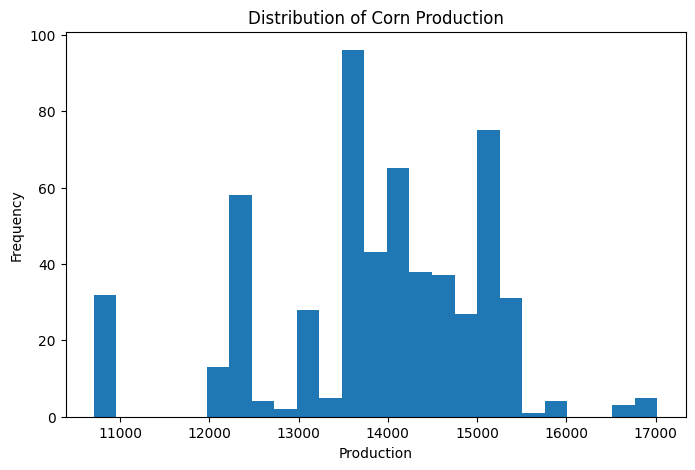

In [ ]:
# Visualize the distribution
plt.figure(figsize=(8,5))
plt.hist(corn_prod["Value"], bins=25)
plt.title("Distribution of Corn Production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()

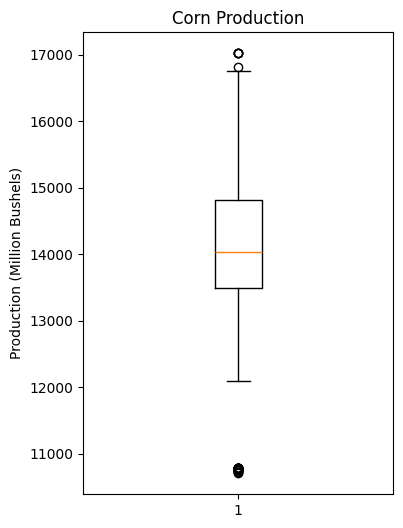

In [ ]:
# Boxplot
plt.figure(figsize=(4,6))
plt.boxplot(corn_prod["Value"])
plt.title("Corn Production")
plt.ylabel("Production (Million Bushels)")
plt.show()

**TIME SERIES**

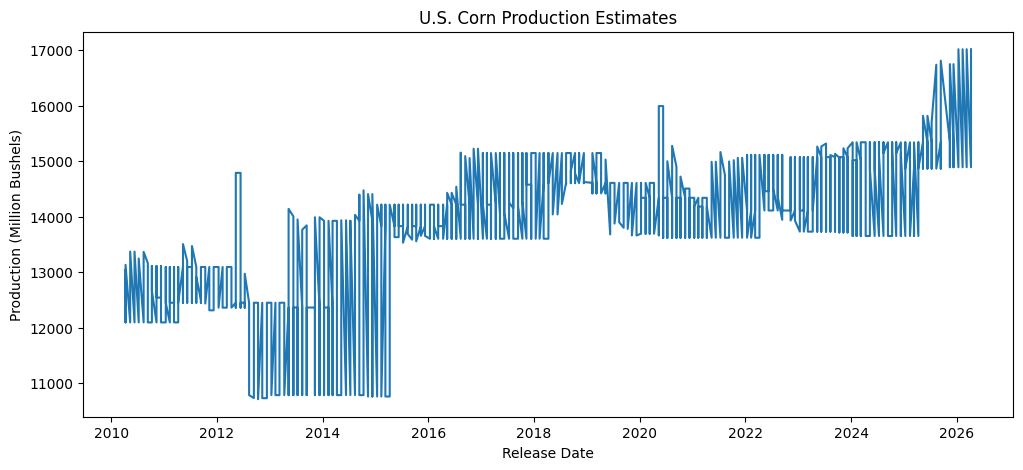

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    corn_prod["ReleaseDate"],
    corn_prod["Value"]
)

plt.title("U.S. Corn Production Estimates")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.show()

How does the USDA revise estimates within a marketing year?

In [ ]:
my = corn_prod[
    corn_prod["MarketYear"] == "2022/23"
].sort_values("ReleaseDate")

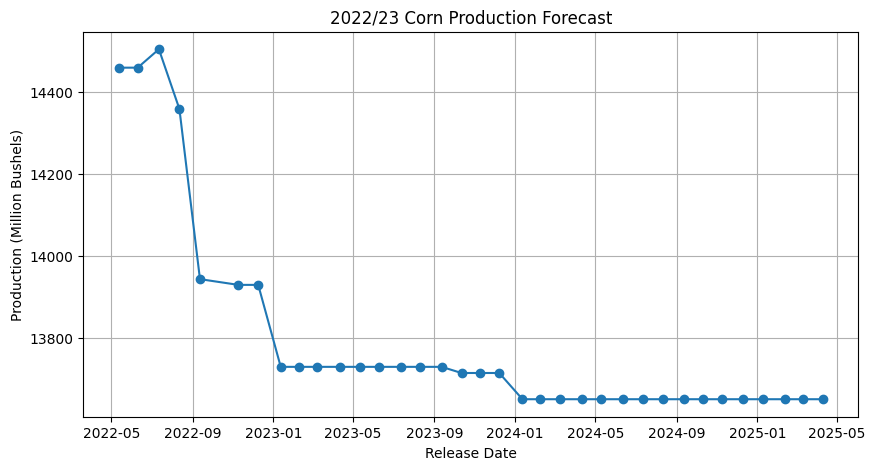

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    my["ReleaseDate"],
    my["Value"],
    marker="o"
)

plt.title("2022/23 Corn Production Forecast")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.grid(True)

plt.show()

This plot suggests that each market year is a sequence of revisions that overlaps into the following market year, not just one observation. That is why there is so much noise in the time series. This suggests that sequential revisions are made to production estimates by the USDA, converging toward the actual value as the market year progresses.

How many reports are there for each market year?

In [ ]:
corn_prod.groupby("MarketYear").size()

,0
MarketYear,
2007/08,1
2008/09,13
2009/10,25
2010/11,36
2011/12,35
2012/13,35
2013/14,35
2014/15,36
2015/16,36


In [ ]:
my[["ReleaseDate", "Value"]]

,ReleaseDate,Value
698201,2022-05-12,14460.0
703165,2022-06-10,14460.0
708129,2022-07-12,14505.0
713135,2022-08-12,14359.0
718141,2022-09-12,13944.0
723147,2022-11-09,13930.0
728153,2022-12-09,13930.0
733159,2023-01-12,13730.0
738165,2023-02-08,13730.0
743171,2023-03-08,13730.0


Observation: Each market year remains in subsequent WASDE reports after the production estimate has stabilized. As a result, older market years contain repeated final estimates. This should be considered during model development because these repeated values are not new information.

Why does the estimate stop changing?

In [ ]:
corn_prod.groupby("MarketYear")["Value"].nunique()

,Value
MarketYear,
2007/08,1
2008/09,1
2009/10,3
2010/11,7
2011/12,9
2012/13,8
2013/14,8
2014/15,7
2015/16,8


This suggests that only the first handful of reports actually revise the estimates

Overlay of several marketing years to ocmpare how different crop years evolved

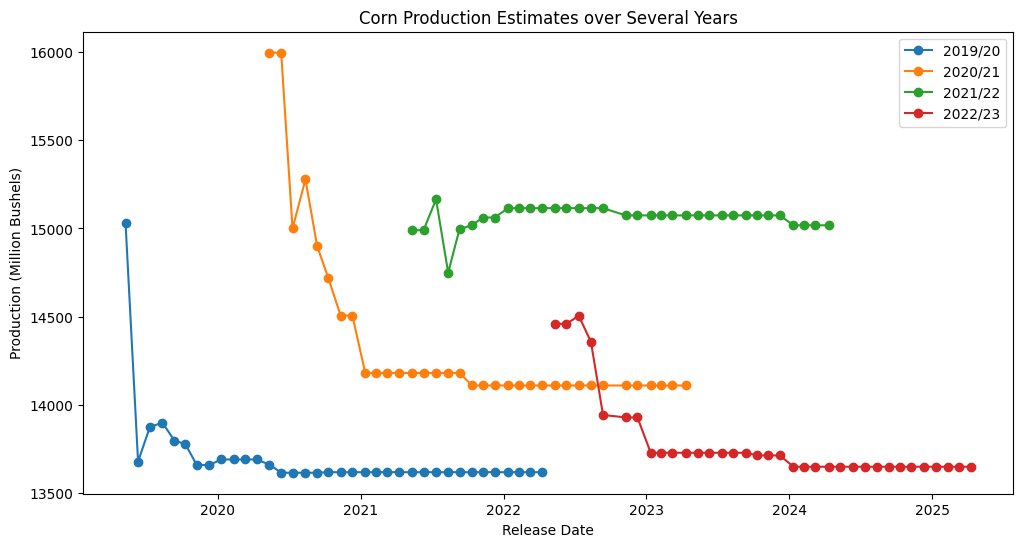

In [ ]:
years = ["2019/20", "2020/21", "2021/22", "2022/23"]

plt.figure(figsize=(12,6))

for year in years:
    temp = corn_prod[
        corn_prod["MarketYear"] == year
    ].sort_values("ReleaseDate")

    plt.plot(
        temp["ReleaseDate"],
        temp["Value"],
        marker="o",
        label=year
    )
plt.title("Corn Production Estimates over Several Years")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.legend()
plt.show()

Each market year is updated monthly through successive WASDE reports. Production estimates are revised as new information becomes available and eventually stabilize once the crop year is complete. After stabilization, the USDA continues reporting the final estimate in later WASDE releases. Therefore, each market year contains both active forecast revisions and repeated finalized values.

# **Repeatable EDA pipeline function**

In [64]:
def run_commodity_attribute_eda(df, commodity, attribute, report_title, market_years=None):

    # -----------------------------
    # 1. Filter data
    # -----------------------------
    data = df[
        (df["Commodity"] == commodity) &
        (df["Attribute"] == attribute) &
        (df["ReportTitle"] == report_title)
    ].copy()

    data = data.sort_values("ReleaseDate")

    print("=" * 70)
    print(f"{commodity} - {attribute}")
    print("=" * 70)

    # -----------------------------
    # 2. Basic structure
    # -----------------------------
    print("\nShape:")
    print(data.shape)

    print("\nFirst rows:")
    display(data.head())

    print("\nInfo:")
    data.info()

    print("\nFull describe:")
    display(data.describe(include="all"))

    # -----------------------------
    # 3. Key date/value checks
    # -----------------------------
    print("\nReleaseDate, MarketYear, Value - first 10:")
    display(data[["ReleaseDate", "MarketYear", "Value"]].head(10))

    print("\nReleaseDate, MarketYear, Value - last 10:")
    display(data[["ReleaseDate", "MarketYear", "Value"]].tail(10))

    # -----------------------------
    # 4. Missing values
    # -----------------------------
    print("\nMissing values:")
    display(data.isna().sum())

    # -----------------------------
    # 5. Summary statistics
    # -----------------------------
    print("\nValue summary statistics:")
    display(data["Value"].describe())

    print("\nMedian value:")
    print(data["Value"].median())

    # -----------------------------
    # 6. Histogram
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(data["Value"], bins=25)
    plt.title(f"Distribution of {commodity} {attribute}")
    plt.xlabel(attribute)
    plt.ylabel("Frequency")
    plt.show()

    # -----------------------------
    # 7. Boxplot
    # -----------------------------
    plt.figure(figsize=(4, 6))
    plt.boxplot(data["Value"].dropna())
    plt.title(f"{commodity} {attribute}")
    plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
    plt.show()

    # -----------------------------
    # 8. Full time series
    # -----------------------------
    plt.figure(figsize=(12, 5))

    plt.plot(
        data["ReleaseDate"],
        data["Value"]
    )

    plt.title(f"U.S. {commodity} {attribute} Estimates")
    plt.xlabel("Release Date")
    plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
    plt.show()

    # -----------------------------
    # 9. Market year comparison plot
    # -----------------------------
    if market_years is not None:
        plt.figure(figsize=(12, 6))

        for year in market_years:
            temp = data[
                data["MarketYear"] == year
            ].sort_values("ReleaseDate")

            plt.plot(
                temp["ReleaseDate"],
                temp["Value"],
                marker="o",
                label=year
            )

        plt.title(f"{commodity} {attribute} Estimates over Several Years")
        plt.xlabel("Release Date")
        plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
        plt.legend()
        plt.show()

    return data

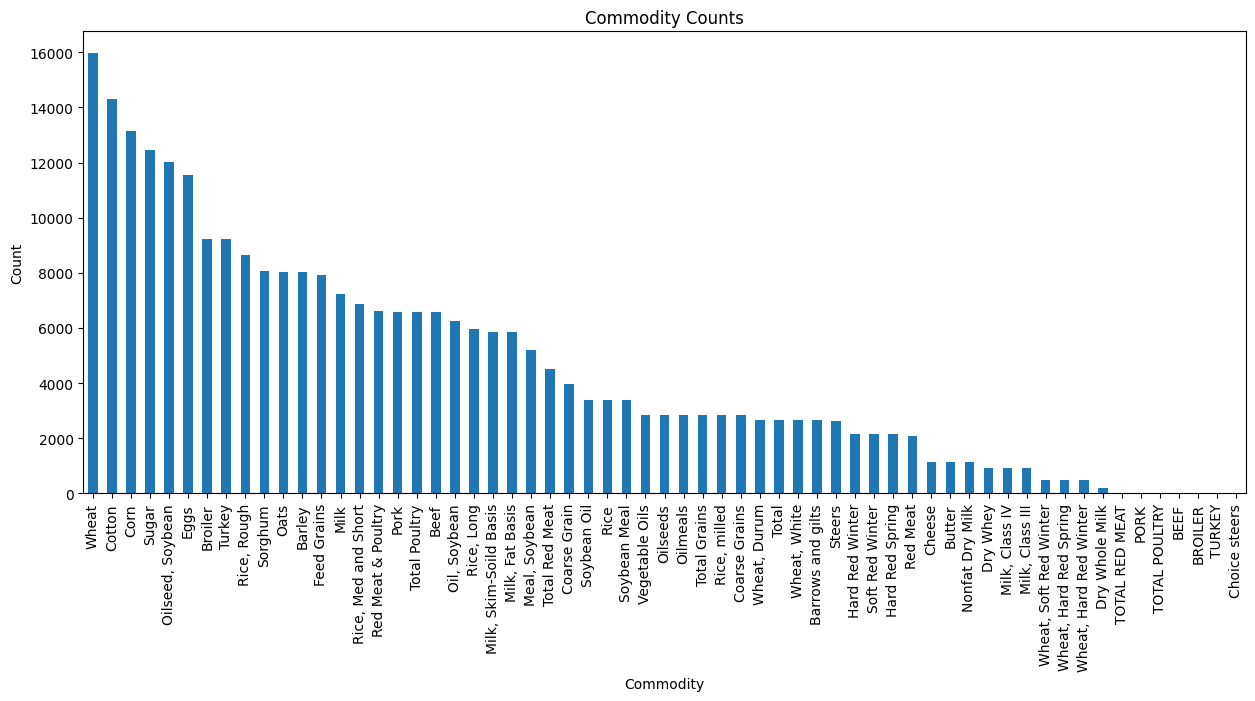

In [59]:
# plot value counts for all commodities sized correctly
plt.figure(figsize=(15,6))
plt.title("Commodity Counts")
plt.xlabel("Commodity")
plt.ylabel("Count")
df_us["Commodity"].value_counts().plot(kind="bar")
plt.show()

Open Market Commodities to prioritize:

- Corn ✅
- Sugar ✅
- Soybean ✅
- Soybean Meal ✅
- Soybean Oil ✅
- Wheat ✅
- Hard Red Winter ✅
- Hard Red Spring ✅
- Cotton ✅
- Rice, Rough ✅
- Oats ✅
- Steers
- Barrows and gilts
- Dry Whey
- Cheese
- Butter
- Milk

In [60]:
# Print all report titles
df_us["ReportTitle"].unique()

array(['U.S. Cotton Supply and Use', 'U.S. Dairy Prices',
       'U.S. Egg Supply and Use',
       'U.S. Feed Grain and Corn Supply and Use',
       'U.S. Meats Supply and Use', 'U.S. Milk Supply and Use',
       'U.S. Quarterly Animal Product Production',
       'U.S. Quarterly Prices for Animal Products',
       'U.S. Rice Supply and Use',
       'U.S. Sorghum, Barley, and Oats Supply and Use',
       'U.S. Soybeans and Products Supply and Use (Domestic Measure)',
       'U.S. Sugar Supply and Use', 'U.S. Wheat by Class: Supply and Use',
       'U.S. Wheat Supply and Use',
       'World and U.S Supply and Use for Grains',
       'World and U.S. Supply and Use for Cotton',
       'World and U.S. Supply and Use for Oilseeds',
       'World Coarse Grain Supply and Use', 'World Corn Supply and Use',
       'World Cotton Supply and Use',
       'World Rice Supply and Use  (Milled Basis)',
       'World Soybean Meal Supply and Use',
       'World Soybean Oil Supply and Use', 'World Soybean

Normalizing hrs and hrw

In [84]:
df_us["Commodity"] = df_us["Commodity"].replace({
    "Wheat, Hard Red Spring": "Hard Red Spring"
})

In [69]:
print(df_us[df_us["ReportTitle"].str.contains("Wheat", case=False, na=False)]["ReportTitle"].unique())

['U.S. Wheat by Class: Supply and Use' 'U.S. Wheat Supply and Use'
 'World Wheat Supply and Use']


In [82]:
print(df_us[df_us["Commodity"].str.contains("Hard Red Spring", case=False, na=False)]["Commodity"].unique())

['Wheat, Hard Red Spring' 'Hard Red Spring']


To find corresponding report title

In [105]:
print(
    df_us[df_us["Commodity"].str.contains("Sugar", case=False, na=False)]
    .groupby(["Commodity", "ReportTitle"])["ReleaseDate"]
    .max()
)

Commodity  ReportTitle              
Sugar      U.S. Sugar Supply and Use   2026-04-09
Name: ReleaseDate, dtype: datetime64[ns]


Running EDA Function

Sugar - Production

Shape:
(567, 16)

First rows:


,WasdeNumber,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
1566,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2007/08,NaN,Annual,8152.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
1588,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,Est.,Annual,7532.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
1610,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Proj.,Annual,7907.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
6349,482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,NaN,Annual,7532.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5
6371,482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Est.,Annual,7847.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5



Info:
<class 'pandas.core.frame.DataFrame'>
Index: 567 entries, 1566 to 925442
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   WasdeNumber            567 non-null    int64         
 1   ReportDate             567 non-null    object        
 2   ReportTitle            567 non-null    object        
 3   Attribute              567 non-null    object        
 4   ReliabilityProjection  0 non-null      object        
 5   Commodity              567 non-null    object        
 6   Region                 567 non-null    object        
 7   MarketYear             567 non-null    object        
 8   ProjEstFlag            378 non-null    object        
 9   AnnualQuarterFlag      567 non-null    object        
 10  Value                  567 non-null    float64       
 11  Unit                   567 non-null    object        
 12  ReleaseDate            567 non-null    datetime64[ns]
 1

,WasdeNumber,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
count,567.000000,567,567,567,0,567,567,567,378,567,567.000000,567,567,567,567.000000,567.000000
unique,NaN,189,1,1,0,1,1,19,2,1,NaN,1,NaN,3,NaN,NaN
top,NaN,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2015/16,Est.,Annual,NaN,"1000 Short Tons, Raw Value",NaN,12:00:00.0000000,NaN,NaN
freq,NaN,3,567,567,NaN,567,567,36,189,567,NaN,567,NaN,453,NaN,NaN
mean,575.216931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8787.291005,NaN,2018-03-25 22:20:57.142857216,NaN,2017.751323,6.460317
min,481.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7532.000000,NaN,2010-04-09 00:00:00,NaN,2010.000000,1.000000
25%,528.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8462.000000,NaN,2014-04-09 00:00:00,NaN,2014.000000,4.000000
50%,575.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8980.000000,NaN,2018-03-08 00:00:00,NaN,2018.000000,6.000000
75%,622.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9233.000000,NaN,2022-03-09 00:00:00,NaN,2022.000000,9.000000
max,670.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9514.000000,NaN,2026-04-09 00:00:00,NaN,2026.000000,12.000000



ReleaseDate, MarketYear, Value - first 10:


...


Missing values:


,0
WasdeNumber,0
ReportDate,0
ReportTitle,0
Attribute,0
ReliabilityProjection,567
Commodity,0
Region,0
MarketYear,0
ProjEstFlag,189
AnnualQuarterFlag,0



Value summary statistics:


,Value
count,567.000000
mean,8787.291005
std,506.946870
min,7532.000000
25%,8462.000000
50%,8980.000000
75%,9233.000000
max,9514.000000



Median value:
8980.0


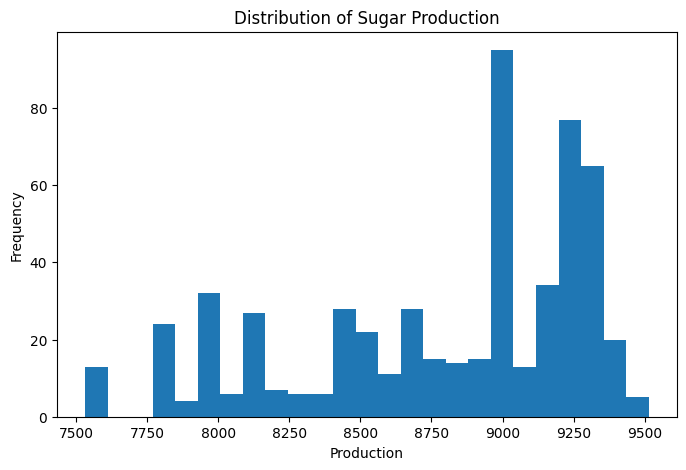

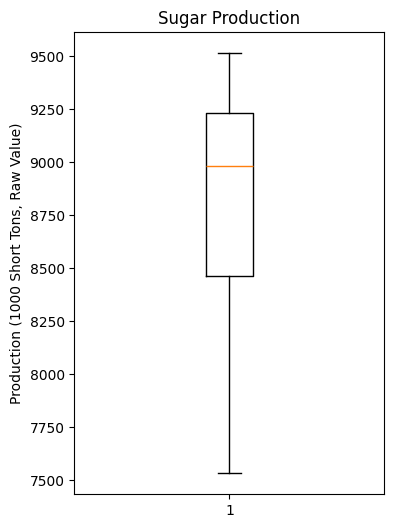

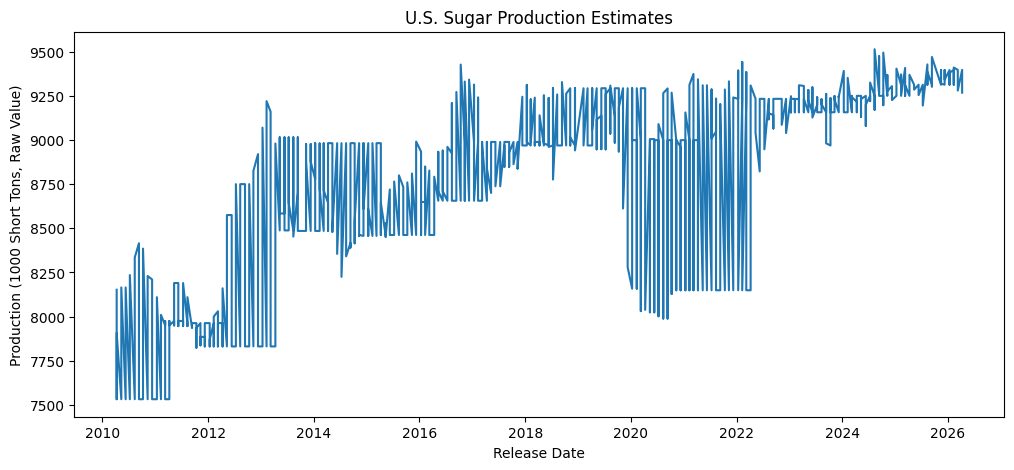

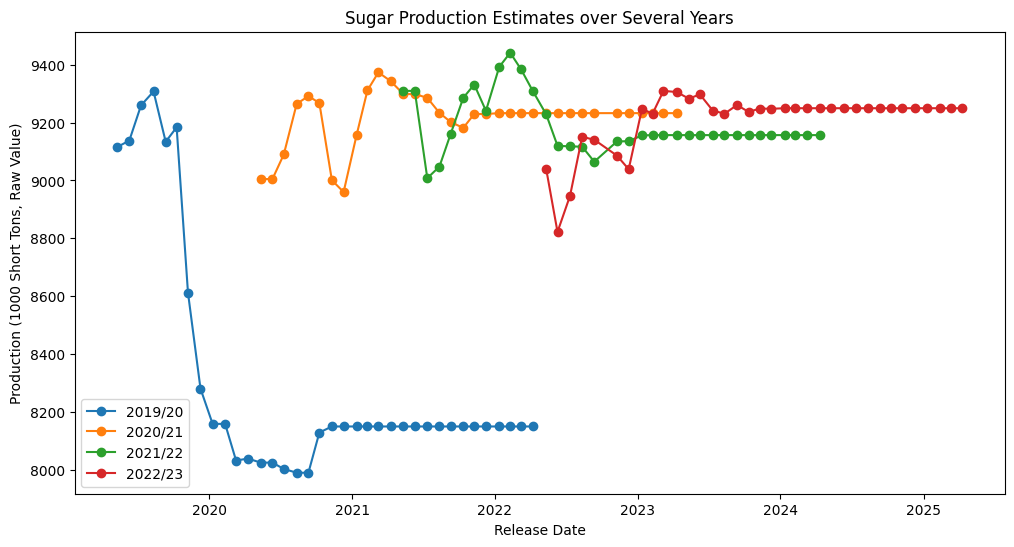

In [108]:
sugar_prod = run_commodity_attribute_eda(
    df=df_us,
    commodity="Sugar",
    attribute="Production",
    report_title="U.S. Sugar Supply and Use",
    market_years=["2019/20", "2020/21", "2021/22", "2022/23"]
)

# **Export the Data**

In [ ]:
# open market commodities
corn = df_us[
    df_us["ReportTitle"] == "U.S. Feed Grain and Corn Supply and Use"
]
soybeans = df_us[
    df_us["ReportTitle"] == "U.S. Soybeans and Products Supply and Use (Domestic Measure)"
]
cotton = df_us[
    df_us["ReportTitle"] == "U.S. Cotton Supply and Use"
]
wheat = df_us[
    df_us["ReportTitle"] == "U.S. Wheat Supply and Use"
]
rice = df_us[
    df_us["ReportTitle"] == "U.S. Rice Supply and Use"
]
oats = df_us[
    df_us["ReportTitle"] == "U.S. Sorghum, Barley, and Oats Supply and Use"
]
hrw = df_us[
    df_us["ReportTitle"] == "U.S. Wheat by Class: Supply and Use"
]
sugar = df_us[
    df_us["ReportTitle"] == "U.S. Sugar Supply and Use"
]

In [110]:
sugar_prod = sugar[
    (sugar["Commodity"] == "Sugar") &
    (sugar["Attribute"] == "Production")
].copy()

In [111]:
sugar_prod.head()

,WasdeNumber,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
1566,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2007/08,NaN,Annual,8152.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
1588,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,Est.,Annual,7532.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
1610,481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Proj.,Annual,7907.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
6349,482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,NaN,Annual,7532.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5
6371,482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Est.,Annual,7847.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5


In [ ]:
# export commodity data subsets to csv for modeling
output_path = Path("../../data/processed/sugar_prod.csv")
sugar_prod.to_csv(output_path, index=False)

# **FORECASTING**


What are we trying to forecast?

- Predict the next monthly USDA revision.

- Predict the final production estimate for a market year.

- Predict the production reported in future WASDE releases